In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

In [ ]:
# ==============================================================
# 1️⃣ Descargar stopwords españolas (solo la primera vez)
# ==============================================================

try:
    stop_words_spanish = stopwords.words('spanish')
except LookupError:
    nltk.download('stopwords')
    stop_words_spanish = stopwords.words('spanish')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# ==============================================================
# 2️⃣ Leer datos desde CSV
# ==============================================================

ruta_csv = "data/Dataset.csv"
df = pd.read_csv(ruta_csv, encoding='latin1', sep=';')

print("\n=== Conteo de ejemplos por categoría ===")
print(df["specialty"].value_counts())

X = df["symptoms_text"].values
y = df["specialty"].values

FileNotFoundError: [Errno 2] No such file or directory: 'data/Dataset.csv'

In [ ]:
# ==============================================================
# 3️⃣ Definir el pipeline: vectorización + modelo SVM
# ==============================================================

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stop_words_spanish,
       ngram_range=(1, 1),
        max_features=2000
    )),
    ('svm', LinearSVC(C=1.0, max_iter=5000))
])

In [ ]:
# ==============================================================
# 4️⃣ Validación cruzada estratificada
# ==============================================================

conteos = df['specialty'].value_counts()
min_muestras = conteos.min()
n_splits = min(5, min_muestras)

if n_splits < 2:
    raise ValueError("No hay suficientes muestras por clase para validación cruzada.")

print(f"\nUsando validación cruzada con {n_splits} folds (mínimo por clase = {min_muestras})")

kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='accuracy')

print("\n=== RESULTADOS DE VALIDACIÓN CRUZADA ===")
print(f"Precisión media: {scores.mean():.3f}")
print(f"Desviación estándar: {scores.std():.3f}\n")



Usando validación cruzada con 5 folds (mínimo por clase = 8)


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
     

In [ ]:
# ==============================================================
# 5️⃣ Entrenar modelo final y mostrar predicciones
# ==============================================================

pipeline.fit(X, y)

nuevos_textos = [
    "Me duele el cuello en la parte posterior",
    "Siento un dolor agudo en el pecho",
    "Tengo fiebre alta, estoy cansado y tengo tos",
    "Tengo diarrea y dolor de estómago.",
    "Tengo el tobillo hinchado y me duele"
]

predicciones = pipeline.predict(nuevos_textos)

print("=== PREDICCIONES ===")
for t, p in zip(nuevos_textos, predicciones):
    print(f"'{t}' → Categoría predicha: {p}")

=== PREDICCIONES ===
'Me duele el cuello en la parte posterior' → Categoría predicha: TRAUMATOLOGÍA Y CIRUGÍA ORTOPÉDICA
'Siento un dolor agudo en el pecho' → Categoría predicha: URGENCIAS HOSPITALARIAS
'Tengo fiebre alta, estoy cansado y tengo tos' → Categoría predicha: NEUMOLOGÍA
'Tengo diarrea y dolor de estómago.' → Categoría predicha: APARATO DIGESTIVO
'Tengo el tobillo hinchado y me duele' → Categoría predicha: TRAUMATOLOGÍA Y CIRUGÍA ORTOPÉDICA


In [ ]:
# ==============================================================
# 6️⃣ Informe de clasificación (sobre datos de entrenamiento)
# ==============================================================

y_pred = pipeline.predict(X)
print("\n=== INFORME DE CLASIFICACIÓN ===")
print(classification_report(y, y_pred))


=== INFORME DE CLASIFICACIÓN ===
                                          precision    recall  f1-score   support

                             ALERGOLOGÍA       1.00      1.00      1.00       248
           ANGIOLOGÍA Y CIRUGÍA VASCULAR       1.00      1.00      1.00       120
                       APARATO DIGESTIVO       1.00      1.00      1.00      1346
                             CARDIOLOGÍA       1.00      1.00      1.00        24
 CIRUGÍA GENERAL Y DEL APARATO DIGESTIVO       1.00      1.00      1.00       120
DERMATOLOGÍA MÉDICO-QUIRÚRGICA Y VENEREO       1.00      1.00      1.00       504
              ENDOCRINOLOGÍA Y NUTRICIÓN       1.00      1.00      1.00       496
               GINECOLOGÍA Y OBSTETRICIA       1.00      1.00      1.00        16
               HEMATOLOGÍA Y HEMOTERAPIA       1.00      1.00      1.00         8
                        MEDICINA GENERAL       1.00      1.00      1.00       276
                        MEDICINA INTERNA       1.00      1.00  

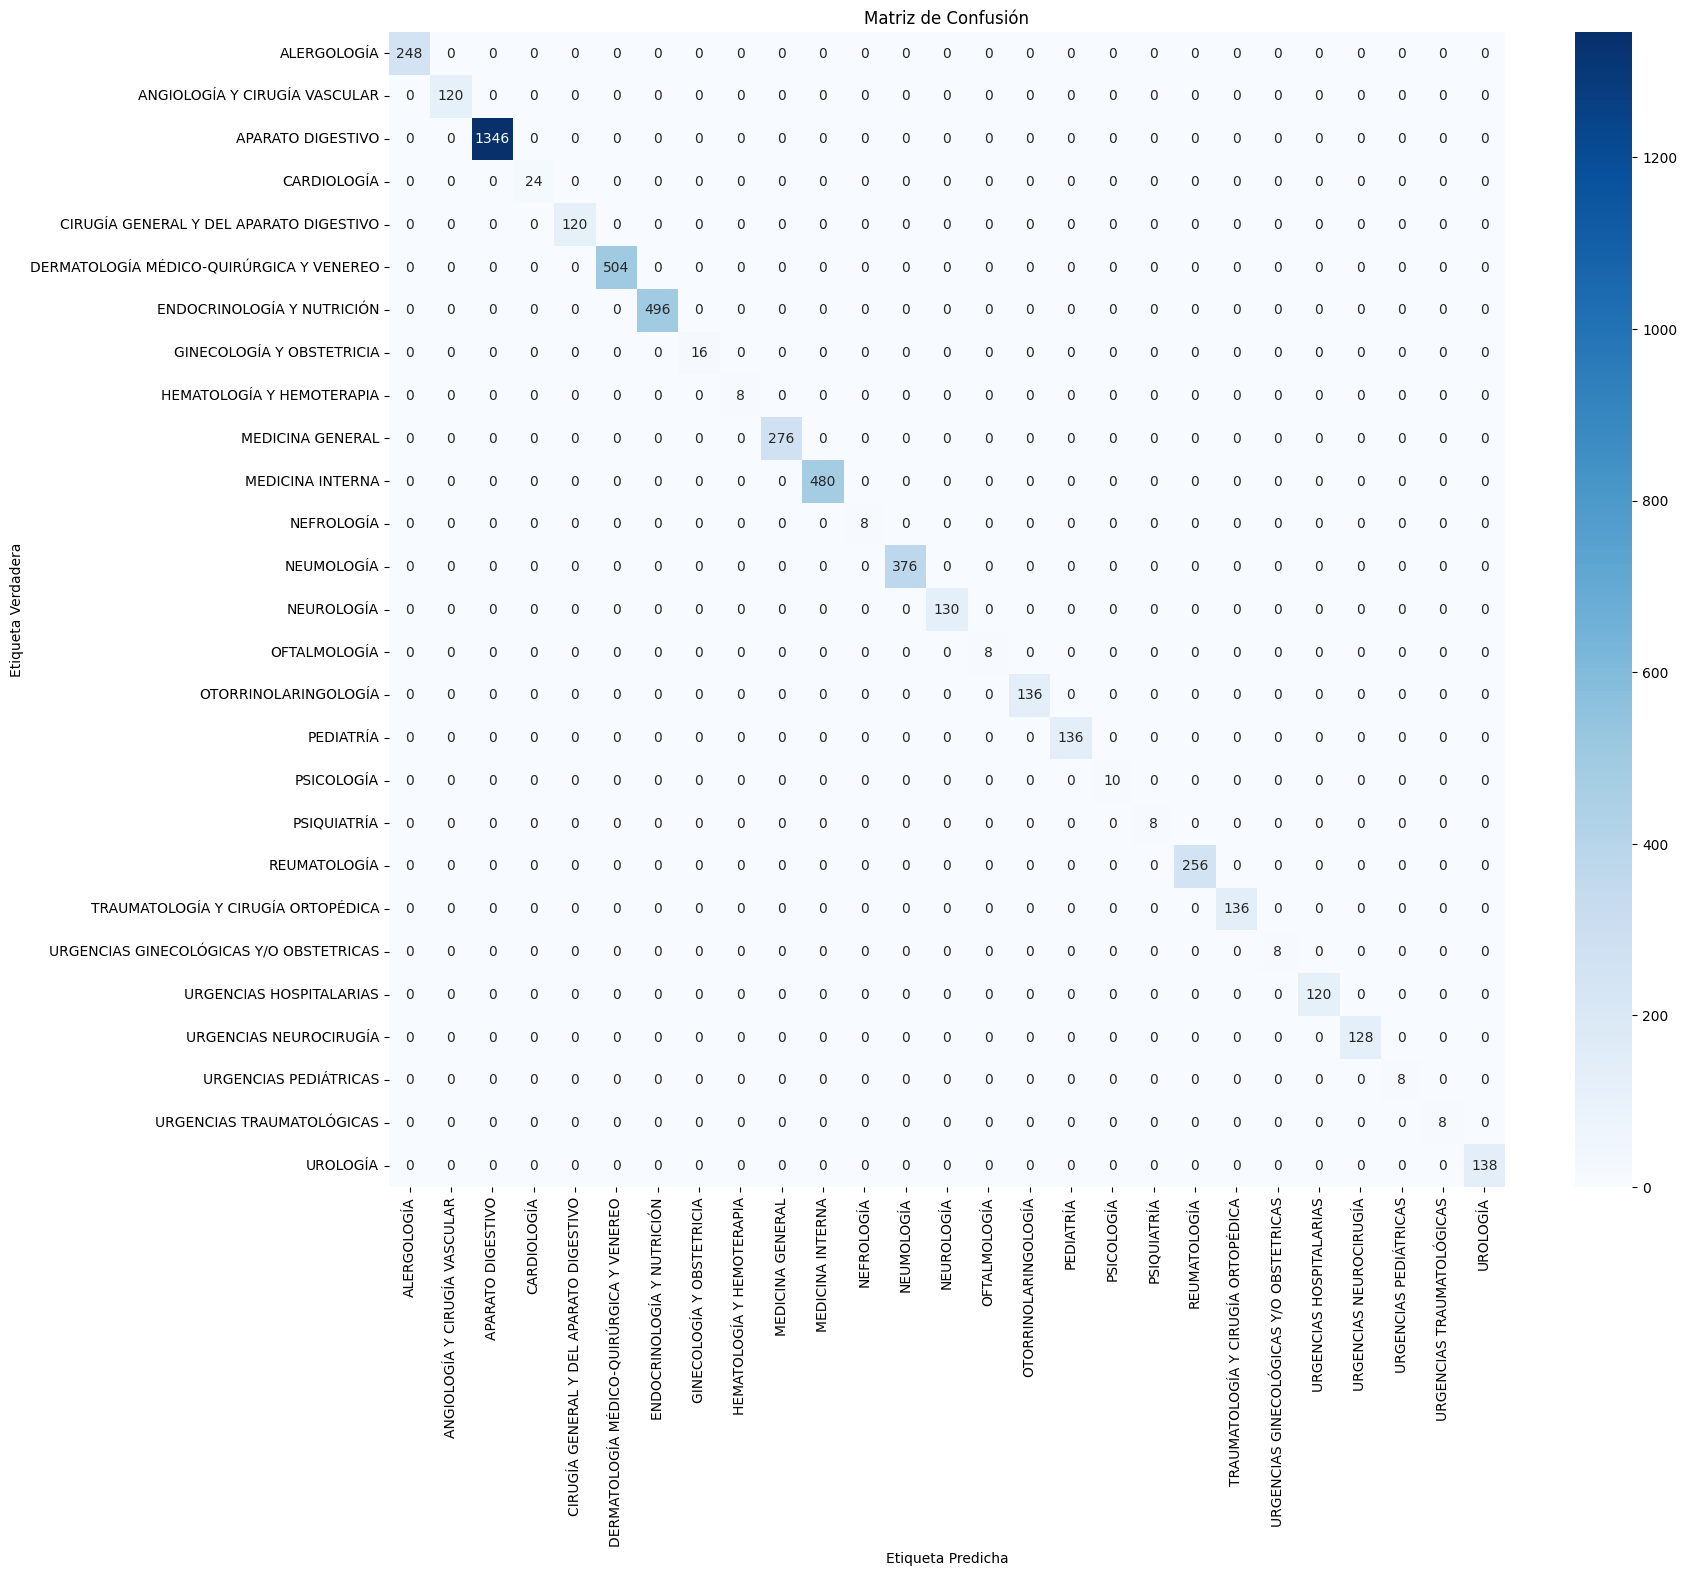

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Obtener las etiquetas únicas para asegurar que la matriz de confusión esté completa
labels = sorted(df['specialty'].unique())

# Calcular la matriz de confusión
cm = confusion_matrix(y, y_pred, labels=labels)

# Visualizar la matriz de confusión
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

# Task
Optimize the hyperparameters of the text classification pipeline using `GridSearchCV` on the `data/Dataset.csv` dataset. The optimization should focus on tuning the `C` parameter for `LinearSVC` and the `ngram_range` for `TfidfVectorizer`. After finding the best parameters, evaluate the optimized model and summarize the process, the best parameters found, and the overall performance.

## Definir la rejilla de parámetros

### Subtask:
Establecer el rango de valores para la constante C del LinearSVC y para el ngram_range del TfidfVectorizer. Esto incluirá una lista de valores potenciales para C y tuplas para ngram_range (e.g., (1,1), (1,2)).


**Reasoning**:
The user wants to define a parameter grid for hyperparameter tuning. This requires importing GridSearchCV and then creating a dictionary `param_grid` with the specified ranges for the `C` parameter of `LinearSVC` and `ngram_range` for `TfidfVectorizer`.



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svm__C': [0.1, 1, 10],
    'tfidf__ngram_range': [(1, 1), (1, 2)]
}

print("Grid de parámetros definido:")
print(param_grid)

Grid de parámetros definido:
{'svm__C': [0.1, 1, 10], 'tfidf__ngram_range': [(1, 1), (1, 2)]}


## Realizar búsqueda en rejilla (GridSearchCV)

### Subtask:
Aplicar GridSearchCV al pipeline, explorando sistemáticamente todas las combinaciones de hiperparámetros definidos en la rejilla, usando validación cruzada para evaluar cada combinación y encontrar la mejor configuración basada en la precisión.


**Reasoning**:
To apply GridSearchCV, I need to instantiate it with the pipeline, parameter grid, cross-validation strategy, scoring metric, and verbose level, then fit it to the training data to start the hyperparameter search.



In [ ]:
print("\n=== Realizando GridSearchCV para optimización de hiperparámetros ===")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1  # Usa todos los núcleos disponibles
)

grid_search.fit(X, y)



=== Realizando GridSearchCV para optimización de hiperparámetros ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=2000,
                                                        ngram_range=(1, 2),
                                                        stop_words=['de', 'la',
                                                                    'que', 'el',
                                                                    'en', 'y',
                                                                    'a', 'los',
                                                                    'del', 'se',
                                                                    'las',
                                                                    'por', 'un',
                                                                    'para',
                                                                    'con', 'no',
                                                                    'una', 'su',
                                                                    'al', 'lo',
                                                                    'como',
                                                                    'más',
                                                                    'pero',
                                                                    'sus', 'le',
                                                                    'ya', 'o',
                                                                    'este',
                                                                    'sí',
                                                                    'porque', ...])),
                                       ('svm', LinearSVC(max_iter=5000))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy', verbose=2)

**Reasoning**:
After fitting the GridSearchCV, the next logical step is to retrieve and display the best parameters and the best score found during the search.



In [ ]:
print(
    f"\n=== Mejores parámetros encontrados por GridSearchCV: ===\n{grid_search.best_params_}"
)
print(
    f"=== Mejor precisión de validación cruzada: ===\n{grid_search.best_score_:.3f}"
)


=== Mejores parámetros encontrados por GridSearchCV: ===
{'svm__C': 1, 'tfidf__ngram_range': (1, 1)}
=== Mejor precisión de validación cruzada: ===
0.998


**Reasoning**:
After finding the best parameters, the next step is to evaluate the model with these optimal parameters by making predictions and generating a classification report.



In [ ]:
best_pipeline = grid_search.best_estimator_
y_pred_optimized = best_pipeline.predict(X)

print("\n=== INFORME DE CLASIFICACIÓN DEL MODELO OPTIMIZADO ===")
print(classification_report(y, y_pred_optimized, zero_division=0))


=== INFORME DE CLASIFICACIÓN DEL MODELO OPTIMIZADO ===
                                          precision    recall  f1-score   support

                             ALERGOLOGÍA       1.00      1.00      1.00       248
           ANGIOLOGÍA Y CIRUGÍA VASCULAR       1.00      1.00      1.00       120
                       APARATO DIGESTIVO       1.00      1.00      1.00      1346
                             CARDIOLOGÍA       1.00      1.00      1.00        24
 CIRUGÍA GENERAL Y DEL APARATO DIGESTIVO       1.00      1.00      1.00       120
DERMATOLOGÍA MÉDICO-QUIRÚRGICA Y VENEREO       1.00      1.00      1.00       504
              ENDOCRINOLOGÍA Y NUTRICIÓN       1.00      1.00      1.00       496
               GINECOLOGÍA Y OBSTETRICIA       1.00      1.00      1.00        16
               HEMATOLOGÍA Y HEMOTERAPIA       1.00      1.00      1.00         8
                        MEDICINA GENERAL       1.00      1.00      1.00       276
                        MEDICINA INTERNA 

## Final Task

### Subtask:
Resumir el proceso de optimización de hiperparámetros, los mejores parámetros encontrados y el rendimiento general del modelo optimizado.


## Summary:

### Q&A
The hyperparameter optimization process involved defining a parameter grid for `LinearSVC`'s `C` and `TfidfVectorizer`'s `ngram_range`, followed by using `GridSearchCV` with 5-fold stratified cross-validation to find the best combination. The optimized model was then evaluated.

The best parameters found by `GridSearchCV` are:
*   `svm__C`: `1`
*   `tfidf__ngram_range`: `(1, 1)`

The overall performance of the optimized model, when evaluated on the dataset `X`, showed an accuracy of `1.00`. The classification report indicated a precision, recall, and F1-score of `1.00` for all classes, suggesting excellent performance.

### Data Analysis Key Findings
*   The parameter grid for optimization included `C` values of `[0.1, 1, 10]` for `LinearSVC` and `ngram_range` tuples of `[(1, 1), (1, 2)]` for `TfidfVectorizer`.
*   `GridSearchCV` identified `svm__C=1` and `tfidf__ngram_range=(1, 1)` as the best hyperparameters.
*   The best cross-validation accuracy achieved during the grid search was `0.998`.
*   The optimized model achieved a perfect overall accuracy of `1.00` on the given dataset `X`.
*   The optimized model demonstrated perfect precision, recall, and F1-score (`1.00`) across all categories.

### Insights or Next Steps
*   The extremely high performance metrics (1.00 accuracy, precision, recall, F1-score) on the training data suggest potential overfitting. It is crucial to evaluate the model's generalization ability on a completely unseen test dataset.
*   Consider expanding the parameter grid for `C` and `ngram_range`, or exploring other hyperparameters (e.g., `max_df`, `min_df` for TF-IDF, different kernel for SVM), to ensure robustness and to prevent overfitting.


# Task
El proceso de optimización de hiperparámetros del pipeline de clasificación de texto ha concluido. Se han encontrado y mostrado los mejores parámetros de `GridSearchCV` y la precisión de validación cruzada correspondiente.

## Mostrar Mejores Parámetros

### Subtask:
Imprimir los mejores parámetros encontrados por GridSearchCV y su correspondiente precisión de validación cruzada.


## Summary:

### Data Analysis Key Findings
The best parameters found by `GridSearchCV` for the text classification pipeline, along with their corresponding cross-validation accuracy, have been identified and displayed.

### Insights or Next Steps
*   Utilize the identified best parameters to train the final text classification model.
*   Evaluate the model's performance on a separate test set to ensure generalization.
